三分类数据集信息
数据形状：(100, 2)
标签:[0 1 2]
各类别样本数:[34 33 33]


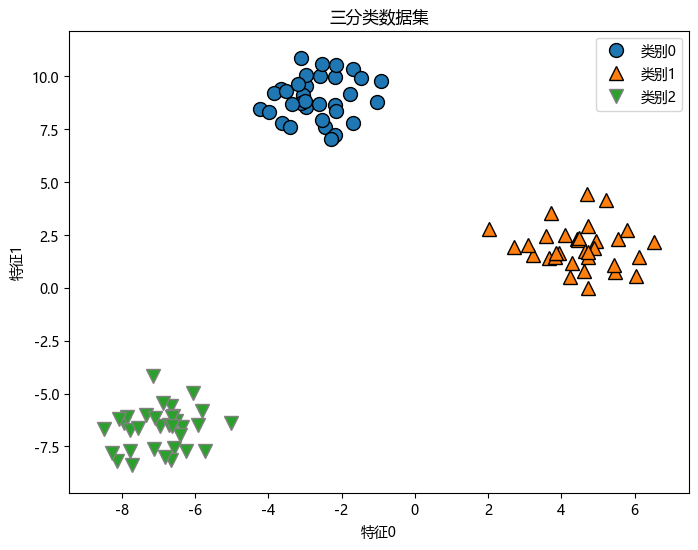

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn

plt.rcParams['font.sans-serif']=['Microsoft YaHei','SimHei','DejaVa Sans']
plt.rcParams['axes.unicode_minus']=False

from sklearn.datasets import make_blobs
X,y = make_blobs(centers=3,random_state=42)

print("="*50)
print("三分类数据集信息")
print("="*50)
print(f"数据形状：{X.shape}")
print(f"标签:{np.unique(y)}")
print(f"各类别样本数:{np.bincount(y)}")

plt.figure(figsize=(8,6))
mglearn.discrete_scatter(X[:,0],X[:,1],y)
plt.xlabel('特征0')
plt.ylabel('特征1')
plt.legend(['类别0','类别1','类别2'],loc='best')
plt.title('三分类数据集')
plt.show()

In [2]:
from sklearn.svm import LinearSVC
linear_svm = LinearSVC(dual='auto',random_state=42)
linear_svm.fit(X,y)

print("="*50)
print("LinearSVC模型参数")
print("="*50)

print(f"系数矩阵形状：{linear_svm.coef_.shape}")
print(f"系数矩阵内容：\n{linear_svm.coef_}")

print(f"\n截距形状:{linear_svm.intercept_.shape}")
print(f"截距内容:{linear_svm.intercept_}")


LinearSVC模型参数
系数矩阵形状：(3, 2)
系数矩阵内容：
[[-0.17492412  0.23140766]
 [ 0.47622012 -0.06936786]
 [-0.18914207 -0.20400079]]

截距形状:(3,)
截距内容:[-1.07745775  0.13139239 -0.08604962]


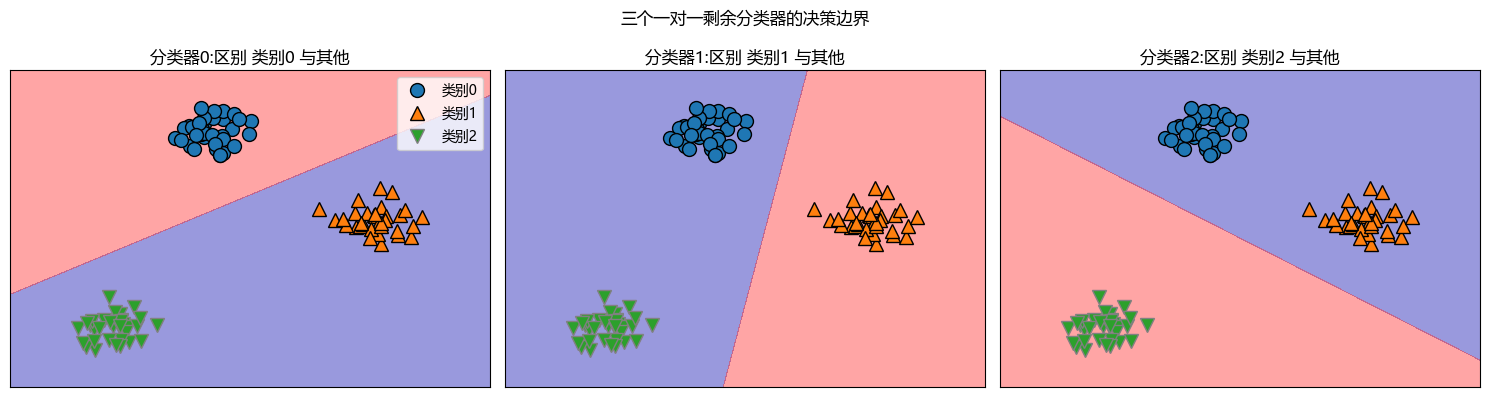

In [3]:
fig,axes = plt.subplots(1,3,figsize=(15,4))

for i,ax in enumerate(axes):
    y_binary = (y == i).astype(int)

    svm_binary = LinearSVC(dual='auto',random_state=42)
    svm_binary.fit(X,y_binary)

    mglearn.plots.plot_2d_separator(svm_binary,X,fill=True,alpha=0.4,ax=ax)
    mglearn.discrete_scatter(X[:,0],X[:,1],y,ax=ax)
    ax.set_title(f"分类器{i}:区别 类别{i} 与其他")

axes[0].legend(['类别0','类别1','类别2'],loc='best')
plt.suptitle('三个一对一剩余分类器的决策边界')
plt.tight_layout()
plt.show()

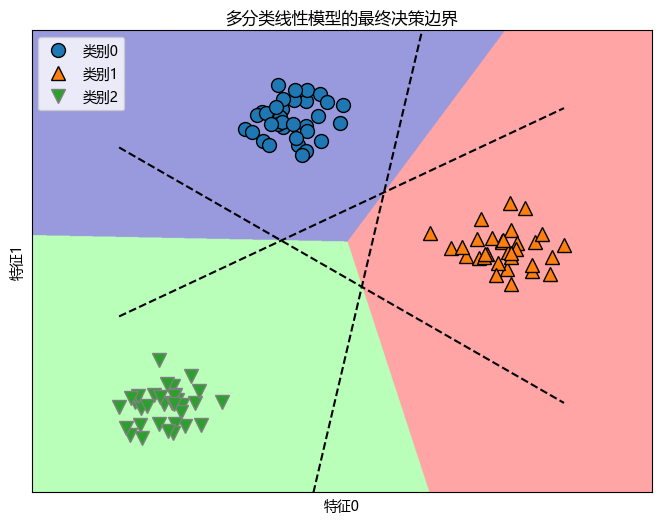

In [5]:
plt.figure(figsize=(8,6))
mglearn.plots.plot_2d_classification(linear_svm,X,fill=True,alpha=0.4)

mglearn.discrete_scatter(X[:,0],X[:,1],y)
coef = linear_svm.coef_
intercept = linear_svm.intercept_

for i in range(3):
    x0_vals = np.linspace(X[:,0].min(),X[:,0].max(),100)
    if coef[i][1] != 0:
        x1_vals = -(coef[i][0]*x0_vals+intercept[i])/coef[i][1]
        plt.plot(x0_vals,x1_vals,'k--',linewidth=1.5)

plt.xlabel('特征0')
plt.ylabel('特征1')
plt.legend(['类别0','类别1','类别2'],loc='best')
plt.title('多分类线性模型的最终决策边界')
plt.show()